In [61]:
import pandas as pd
import requests
from bs4 import BeautifulSoup as bs
import re
import matplotlib.pyplot as plt
import seaborn as sns

###### WEB SCRAPING ------------------
def load_data(url):
    response = requests.get(url)
    response.raise_for_status()
    return response.text

def get_html_content(html):
    soup = bs(html, 'html.parser')
    wines = soup.find_all('div', class_=['product-item', 'product-item--vertical', '1/3--tablet-and-up'])
    wine_list = []
    
    for wine in wines:
        # [All your extraction logic here]
        # ... 
        wine_list.append({
            'name': name_text,
            'vendor': vendor_text,
            'description': description_text,
            'price': price_text,
            'compare_price': compare_price_text,
            'rating': rating_value,
            'reviews': reviews_text,
            'stock': stock_text
        })
    return wine_list

###### DATA TRANSFORMATION ------------------
def transform_scraped_data(wine_list):
    """
    Convert scraped data to match the cleaning function's expected format
    """
    df = pd.DataFrame(wine_list)
    
    # Map scraped columns to cleaning function's expected columns
    df['product_name'] = df['name']
    df['product_price'] = df['price'].astype(str)
    df['product_seller'] = df['vendor']
    df['product_rating'] = df['rating']  # This gets deleted later in cleaning
    
    # Add missing columns with default values
    df['product_type'] = None  # Will be filled with "Red" in cleaning
    df['product_country'] = None  # Will be filled with "Australia" in cleaning
    df['product_region'] = None  # Will be filled with mode in cleaning
    df['product_variety'] = None  # Will be filled with mode in cleaning
    df['product_price_range'] = None  # Will be filled with mode in cleaning
    df['product_size'] = None  # Will be set to "750ml" in cleaning
    df['product_vintage'] = None  # Will be filled with mode in cleaning
    df['product_closure'] = None  # Will be set to "Screw Cap" in cleaning
    
    # Drop original scraped columns
    columns_to_drop = ['name', 'vendor', 'description', 'price', 'compare_price', 'rating', 'reviews', 'stock']
    df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])
    
    return df

##### LOAD & DATAFRAME ------------------
def get_wine_df(file_path):
    """
    Load wine data from CSV into a DataFrame.
    Supports 'wineddrop.csv'.
    """
    if file_path.endswith(".csv"):
        df = pd.read_csv(file_path)
    else:
        raise ValueError("Unsupported file format. Please use .csv")

    print(f"✅ Loaded {len(df)} rows from {file_path}")
    return df

####### CLEANING FUNCTION ------------------
def clean_wine_data(df):
    """
    Clean the wine dataset by handling missing values and formatting columns
    """
    # Make a copy to avoid modifying the original
    df_clean = df.copy()

    # Cleaning operations
    df_clean.product_type = df_clean.product_type.fillna("Red")
    df_clean['product_price'] = df_clean['product_price'].str.replace('Sale price', '', case=False).str.strip()
    df_clean.product_country = df_clean.product_country.fillna("Australia")
    df_clean['product_seller'] = df_clean['product_seller'].fillna(df_clean['product_seller'].mode()[0])
    df_clean['product_region'] = df_clean['product_region'].fillna(df_clean['product_region'].mode()[0])
    df_clean['product_variety'] = df_clean['product_variety'].fillna(df_clean['product_variety'].mode()[0])
    df_clean['product_price_range'] = df_clean['product_price_range'].fillna(df_clean['product_price_range'].mode()[0])
    df_clean["product_size"] = "750ml"
    df_clean['product_vintage'] = df_clean['product_vintage'].fillna(df_clean['product_vintage'].mode()[0])
    df_clean['product_closure'] = df_clean['product_closure'].astype(str).replace(r'\d+', 'Screw Cap', regex=True)
    df_clean['year'] = df_clean['product_name'].str.extract(r'(\d{4})')
    df_clean['product_name'] = df_clean['product_name'].str.replace(r'^\d{4}\s*', '', regex=True)
    df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
    df_clean['year'] = df_clean['year'].fillna(df_clean['year'].median()).astype(int)
    
    if "product_rating" in df_clean.columns:
        del df_clean["product_rating"]

    return df_clean



In [62]:
         ######## STATISTICS ------------------
def summary_statistics(df_clean):
    print("\n📊 DataFrame Shape:", df_clean.shape)  # Fixed: changed df to df_clean
    print("\n📈 Statistiques :")
    print(df_clean[['product_price', 'year']].describe())

#### VISUALISATION .................
def visualize_data(df_clean):
    # Most Popular Wine
    plt.figure(figsize=(10, 6))
    df_clean['product_name'].value_counts().head(10).plot(kind='bar')
    plt.title('Top 10 Most Frequent Wines')
    plt.xlabel('Product Name')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('top_10_wines.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    
    ########   MOST FREQUENT PRODUCTS .....    
    # Group and count number of wines per vendor
    vendor_product_counts = (
        df_clean.groupby(['product_seller', 'product_name'])
        .size()
        .reset_index(name='count')
    )

    # Get top 20 most frequent product names overall
    top_products = (
        df_clean['product_name']
        .value_counts()
        .head(20)
        .index
    )

    # Filter the grouped data to include only those top 20 products
    vendor_product_counts_top = vendor_product_counts[vendor_product_counts['product_name'].isin(top_products)]

    # Pivot for plotting (sellers as index, product names as columns)
    pivot_table = vendor_product_counts_top.pivot(
        index='product_seller',
        columns='product_name',
        values='count'
    ).fillna(0)

    # Keep only top 10 sellers by total number of products
    top_sellers = pivot_table.sum(axis=1).sort_values(ascending=False).head(10).index
    pivot_table_top = pivot_table.loc[top_sellers]

    # Plot stacked bar chart
    pivot_table_top.plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title('Top 20 Most Frequent Products per Vendor')
    plt.xlabel('Product Seller')
    plt.ylabel('Number of Products Sold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Product Name', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
    plt.tight_layout()
    plt.savefig('top20_products_per_vendor.png', dpi=300, bbox_inches='tight')
    plt.show()

    ########    PRODUCTS PER REGION 
    
    # Group by region and count number of wines
    region_counts = df_clean['product_region'].value_counts()  # Added this line

    # Group small regions into "Other"
    top_regions = region_counts.head(10)
    other_count = region_counts[10:].sum()  # Fixed: changed 8 to 10
    if other_count > 0:
        top_regions = pd.concat([top_regions, pd.Series({'Other': other_count})])

    plt.figure(figsize=(10, 8))
    top_regions.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    plt.title('Distribution of Wines by Region', fontsize=14, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.savefig('wines_per_region.png', dpi=300, bbox_inches='tight')
    plt.show()

    #### Wines per Year
    # Group by year and count number of wines
    year_counts = df_clean['year'].value_counts()

    # Plot the top 10 years by total number of wines
    plt.figure(figsize=(10, 6))
    year_counts.plot(kind='bar', color='skyblue')
    plt.title('Number of Wines per Year')
    plt.xlabel('Year')
    plt.ylabel('Number of Wines')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('wines_per_year.png', dpi=300, bbox_inches='tight')
    plt.show()
 
    ############  PRICE PER PODUCT  .......

    # --- CLEAN PRICE COLUMN ---
    df_clean['product_price'] = (
    df_clean['product_price']
    .astype(str)
    .str.replace(r'[^0-9.]', '', regex=True)
    .astype(float)
    )

    # --- SORTED BAR CHART ---
    top20_prices = (
    df_clean[['product_name', 'product_price']]
    .head(20)
    .sort_values(by='product_price', ascending=False)
    )

    plt.figure(figsize=(12, 6))
    plt.bar(top20_prices['product_name'], top20_prices['product_price'], color='skyblue')

    plt.title('Top 20 Wines Sorted by Price (Highest to Lowest)')
    plt.xlabel('Product Name')
    plt.ylabel('Price ($)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('top20_wine_prices_sorted.png', dpi=300, bbox_inches='tight')
    plt.show()



    #####   Top 10 Regions – Wines Sold by Seller.....

    # --- Group data by seller and region, counting number of products sold ---
    seller_region_counts = (
    df_clean.groupby(['product_seller', 'product_region'])['product_name']
    .count()
    .reset_index(name='count')
    )

    # --- Get top 10 regions by total sales ---
    top_regions = (
    seller_region_counts.groupby('product_region')['count']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
    )

    # Filter data for only top 10 regions
    top_data = seller_region_counts[seller_region_counts['product_region'].isin(top_regions)]

    # --- PLOT ---
    plt.figure(figsize=(12, 6))

    # Assign numeric x-positions for regions (for cleaner scatter)
    region_order = list(top_regions)
    region_pos = {region: i for i, region in enumerate(region_order)}

    # Plot each seller’s sales per region
    for seller in top_data['product_seller'].unique():
        subset = top_data[top_data['product_seller'] == seller]
        plt.scatter(
            [region_pos[r] for r in subset['product_region']],
            subset['count'],
            s=subset['count'] * 10,  # bubble size = number sold
            alpha=0.7,
            label=seller
        )

    # --- STYLE ---
    plt.title('Top 10 Regions – Wines Sold by Seller')
    plt.xlabel('Region')
    plt.ylabel('Number of Wines Sold')
    plt.xticks(ticks=range(len(region_order)), labels=region_order, rotation=45, ha='right')
    plt.legend(title='Seller', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('top10_seller_vs_region_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    

########## MODEL EVALUATION ................. 
def evaluate_model(y_true, y_pred, problem_type='classification'): 
    """ Evaluate model performance using appropriate metrics. """ 
    if problem_type == 'classification': 
        accuracy = sklearn.metrics.accuracy_score(y_true, y_pred) 
        print(f"Accuracy: {accuracy:.4f}") 
        print("\nClassification Report:") 
        print(sklearn.metrics.classification_report(y_true, y_pred)) 
    else: 
        # regression 
        mae = sklearn.metrics.mean_absolute_error(y_true, y_pred) 
        mse = sklearn.metrics.mean_squared_error(y_true, y_pred) 
        rmse = np.sqrt(mse) 
        r2 = sklearn.metrics.r2_score(y_true, y_pred) 
        print(f"Mean Absolute Error (MAE): {mae:.4f}") 
        print(f"Root Mean Squared Error (RMSE): {rmse:.4f}") 
        print(f"R² Score: {r2:.4f}")

y_true = [3, 5, 2.5, 7]
y_pred = [2.5, 5, 4, 8]
evaluate_model(y_true, y_pred, problem_type='regression')


Mean Absolute Error (MAE): 0.7500
Root Mean Squared Error (RMSE): 0.9354
R² Score: 0.7241


✅ Loaded 194 rows from wineddrop.csv

 Data cleaning completed!
Cleaned data:
                                product_name product_price  \
0  M&J Becker Wines Hunter Valley Chardonnay        $32.00   
1                    Mercer Wines Chardonnay        $28.00   
2                 Mercer Wines PF Pinot Gris        $24.00   
3                 Mercer Wines Montepulciano        $32.00   
4       Express Winemakers Drinking Wine Red        $28.00   

  product_price_range product_type product_body    product_variety  \
0          $31 to $40        White         Body         Chardonnay   
1         $30 or Less        White         Body         Chardonnay   
2         $30 or Less        White         Body  Pinot Gris/Grigio   
3          $31 to $40          Red         Body      Montepulciano   
4         $30 or Less          Red         Body             Shiraz   

  product_country  product_region product_size product_vintage  \
0       Australia   Hunter Valley        750ml            2024

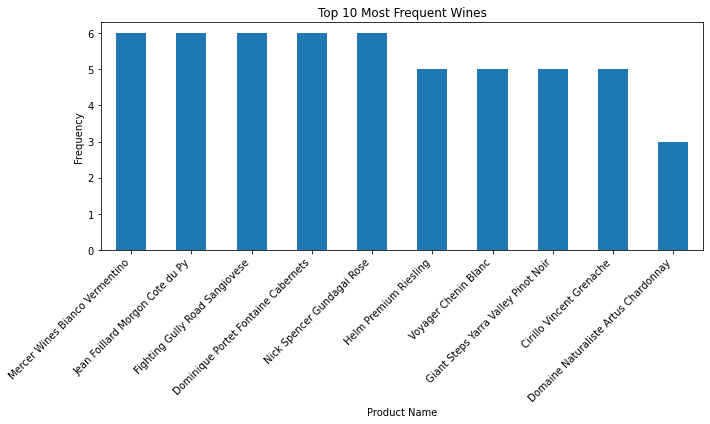

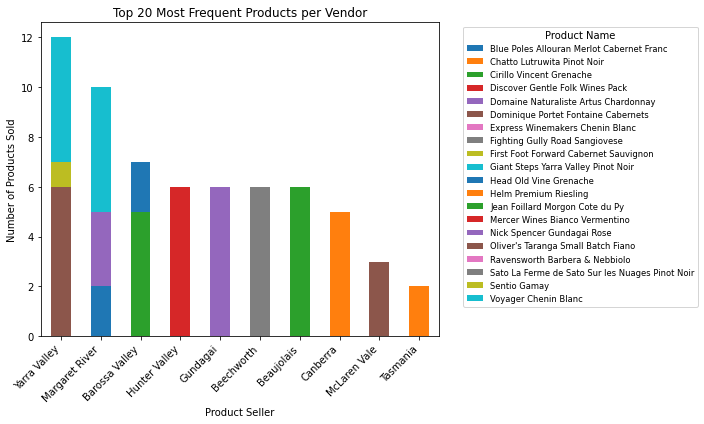

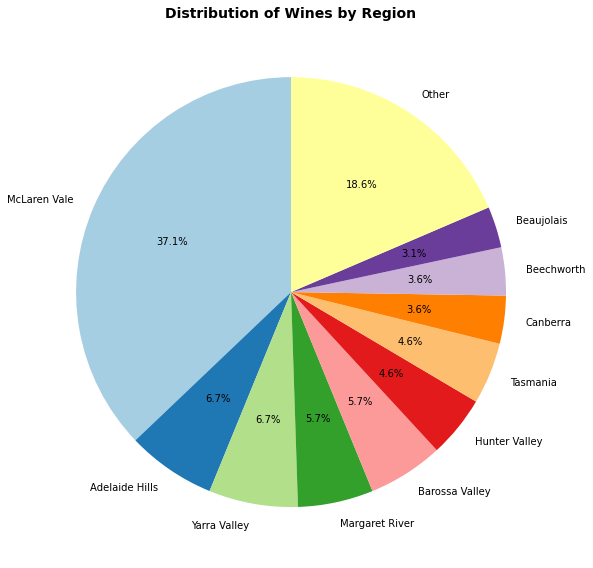

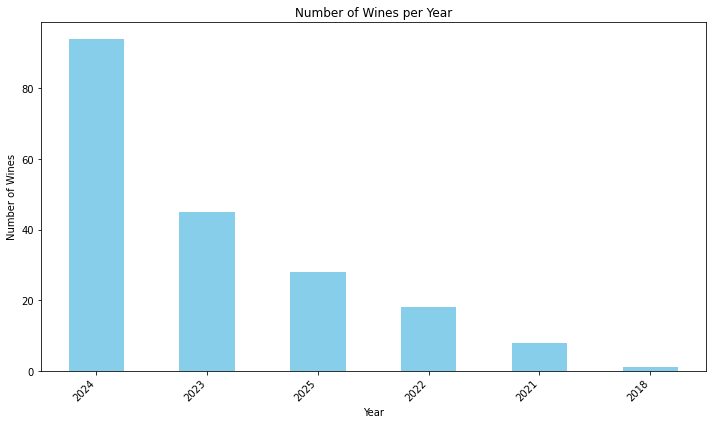

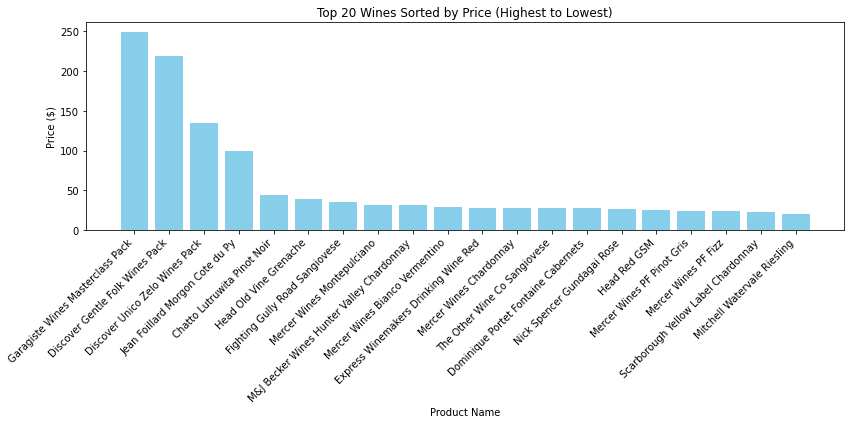

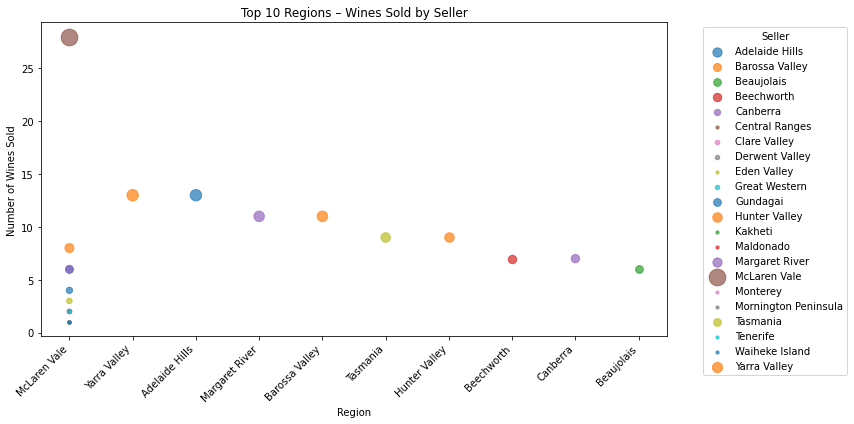

In [63]:


# ------------------ MAIN EXECUTION ------------------
if __name__ == "__main__":
    # Load data
    df = get_wine_df("wineddrop.csv") 
    #print("Raw data:")
    #print(df.head())  # Fixed: added parentheses
    
    # Clean data
    df_clean = clean_wine_data(df)  # Fixed function name
    print("\n Data cleaning completed!")
    print("Cleaned data:")
    print(df_clean.head())
    
    # Save cleaned data
    df_clean.to_csv("wineddrop_clean.csv", index=False) 
    print("💾 Cleaned data saved to 'wineddrop_clean.csv'")
    
    # CALL THE FUNCTIONS - THIS IS WHAT MAKES THEM RUN
    summary_statistics(df_clean)
    visualize_data(df_clean)


MODEL TRAINING AND PRÉDICTIONS OF WINE PRODUCTION

 Année de prédiction : 2026
Mean Absolute Error (MAE): 6.0240
Root Mean Squared Error (RMSE): 7.8582
R² Score: -10.5208

 PRÉVISION DE LA PRODUCTION PAR TYPE DE VIN (2026) :
     product_type  predicted_production
6           White                17.700
3             Red                14.790
5       Sparkling                 6.285
4            Rosé                 5.270
2    Chenin Blanc                 3.615
0  Adelaide Hills                 2.245
1           Amber                 1.870
Mean Absolute Error (MAE): 3.8775
Root Mean Squared Error (RMSE): 5.3788
R² Score: -2.5823

 PRÉVISION DE LA PRODUCTION PAR RÉGION (2026) :
          product_region  predicted_production
22          McLaren Vale                19.945
23  Mornington Peninsula                11.075
24                Orange                 7.995
20        Margaret River                 7.065
21           Marlborough                 6.725
19           King Valley        

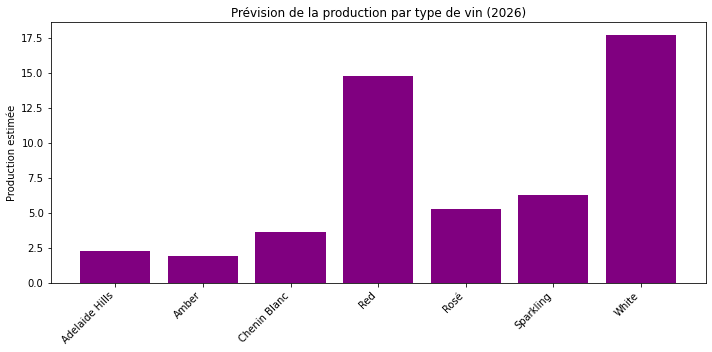

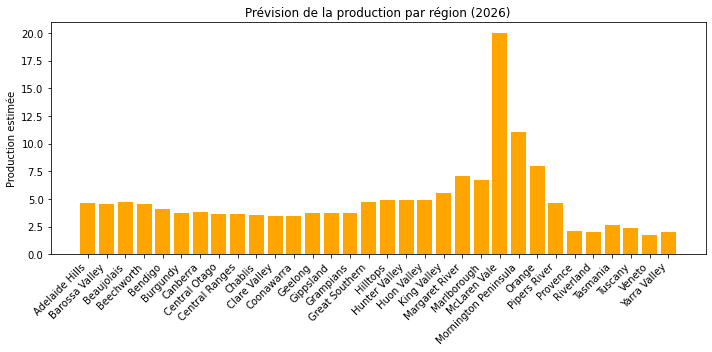


 Fichiers sauvegardés : production_by_type_2026.csv, production_by_region_2026.csv


In [64]:
    # 5. PRÉDICTION DE LA PRODUCTION PAR TYPE DE VIN ET PAR RÉGION
    print("\n" + "="*60)
    print("MODEL TRAINING AND PRÉDICTIONS OF WINE PRODUCTION")
    print("="*60)

    # Déterminer automatiquement l'année suivante à prédire
    df_clean['year'] = df_clean['year'].astype(int)
    next_year = df_clean['year'].max() + 1
    print(f"\n Année de prédiction : {next_year}")

    # --- (1) Production par type de vin ---
    production_by_type = df_clean.groupby(['year', 'product_type']).size().reset_index(name='production')

    le_type = LabelEncoder()
    production_by_type['product_type_encoded'] = le_type.fit_transform(production_by_type['product_type'])

    X_type = production_by_type[['year', 'product_type_encoded']]
    y_type = production_by_type['production']

    X_train_type, X_test_type, y_train_type, y_test_type = train_test_split(
        X_type, y_type, test_size=0.2, random_state=42
    )

    model_type = RandomForestRegressor(n_estimators=200, random_state=42)
    model_type.fit(X_train_type, y_train_type)
    y_pred_type = model_type.predict(X_test_type)
    evaluate_model(y_test_type, y_pred_type, problem_type='regression')

    # Prédiction pour l’année suivante
    next_year_type = pd.DataFrame({
        'year': [next_year] * len(le_type.classes_),
        'product_type_encoded': range(len(le_type.classes_))
    })
    next_year_type['product_type'] = le_type.inverse_transform(next_year_type['product_type_encoded'])
    next_year_type['predicted_production'] = model_type.predict(next_year_type[['year', 'product_type_encoded']])

    print(f"\n PRÉVISION DE LA PRODUCTION PAR TYPE DE VIN ({next_year}) :")
    print(next_year_type[['product_type', 'predicted_production']].sort_values(by='predicted_production', ascending=False))


    # --- (2) Production par région ---
    production_by_region = df_clean.groupby(['year', 'product_region']).size().reset_index(name='production')

    le_region = LabelEncoder()
    production_by_region['product_region_encoded'] = le_region.fit_transform(production_by_region['product_region'])

    X_region = production_by_region[['year', 'product_region_encoded']]
    y_region = production_by_region['production']

    X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
        X_region, y_region, test_size=0.2, random_state=42
    )

    model_region = RandomForestRegressor(n_estimators=200, random_state=42)
    model_region.fit(X_train_reg, y_train_reg)
    y_pred_reg = model_region.predict(X_test_reg)
    evaluate_model(y_test_reg, y_pred_reg, problem_type='regression')

    # Prédiction régionale pour l’année suivante
    next_year_region = pd.DataFrame({
        'year': [next_year] * len(le_region.classes_),
        'product_region_encoded': range(len(le_region.classes_))
    })
    next_year_region['product_region'] = le_region.inverse_transform(next_year_region['product_region_encoded'])
    next_year_region['predicted_production'] = model_region.predict(next_year_region[['year', 'product_region_encoded']])

    print(f"\n PRÉVISION DE LA PRODUCTION PAR RÉGION ({next_year}) :")
    print(next_year_region[['product_region', 'predicted_production']].sort_values(by='predicted_production', ascending=False))


    # --- (3) Production totale tous vins confondus ---
    total_production = df_clean.groupby('year').size().reset_index(name='production')

    X_total = total_production[['year']]
    y_total = total_production['production']

    model_total = RandomForestRegressor(n_estimators=200, random_state=42)
    model_total.fit(X_total, y_total)

    predicted_total_next_year = model_total.predict([[next_year]])[0]
    print(f"\n PRÉVISION DU NOMBRE TOTAL DE VINS PRODUITS EN {next_year} : {predicted_total_next_year:.0f}")

    # --- Visualisations ---
    plt.figure(figsize=(10, 5))
    plt.bar(next_year_type['product_type'], next_year_type['predicted_production'], color='purple')
    plt.title(f"Prévision de la production par type de vin ({next_year})")
    plt.ylabel("Production estimée")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("predicted_production_by_type.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.bar(next_year_region['product_region'], next_year_region['predicted_production'], color='orange')
    plt.title(f"Prévision de la production par région ({next_year})")
    plt.ylabel("Production estimée")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig("predicted_production_by_region.png", dpi=300)
    plt.show()

    # Sauvegarde des résultats
    next_year_type.to_csv(f'production_by_type_{next_year}.csv', index=False)
    next_year_region.to_csv(f'production_by_region_{next_year}.csv', index=False)
    print(f"\n Fichiers sauvegardés : production_by_type_{next_year}.csv, production_by_region_{next_year}.csv")
